In [ ]:
# %pip install optuna 

import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from importlib import reload
import src.utils.purged_cv 
reload(src.utils.purged_cv )
from src.utils.purged_cv import PurgedTimeSeriesSplit
from sklearn.metrics import ndcg_score
import matplotlib.pyplot as plt

## Helper functions

In [212]:
def backtest_monthly_dollar(
    test_df,
    pred_col="pred",
    long_class=None,
    top_pct=None,
    short_class=None,
    short_pct=None,
    price_col="close",
    initial_capital=10000,
    transaction_cost_bps=10,
    monthly_contribution=0,
    short_term_tax_rate=0.35,
    borrow_cost_annual=0.03
):

    if long_class is None and top_pct is None:
        raise ValueError("Must specify either long_class or top_pct")

    df = test_df.copy()
    df = df.sort_values("date")
    df["year_month"] = df["date"].dt.to_period("M")

    capital = initial_capital
    portfolio_value_history = []
    turnover_history = []

    months = df["year_month"].unique()

    for i, month in enumerate(months):

        month_data = df[df["year_month"] == month]
        month_dates = month_data["date"].sort_values()
        first_date, last_date = month_dates.iloc[0], month_dates.iloc[-1]

        first_day = month_data[month_data["date"] == first_date]
        last_day = month_data[month_data["date"] == last_date]

        if i > 0:
            capital += monthly_contribution

        # =========================
        # LONG SELECTION
        # =========================
        if long_class is not None:
            long_selected = first_day[first_day[pred_col] == long_class]
        else:
            cutoff = first_day[pred_col].quantile(1 - top_pct)
            long_selected = first_day[first_day[pred_col] >= cutoff]

        long_tickers = long_selected["ticker"].unique()

        # =========================
        # SHORT SELECTION
        # =========================
        short_tickers = []

        if short_class is not None:
            short_selected = first_day[first_day[pred_col] == short_class]
            short_tickers = short_selected["ticker"].unique()

        elif short_pct is not None:
            cutoff = first_day[pred_col].quantile(short_pct)
            short_selected = first_day[first_day[pred_col] <= cutoff]
            short_tickers = short_selected["ticker"].unique()

        n_long = len(long_tickers)
        n_short = len(short_tickers)

        if n_long == 0 and n_short == 0:
            portfolio_value_history.append(capital)
            turnover_history.append(0)
            continue

        # =========================
        # DOLLAR NEUTRAL WEIGHTS
        # =========================
        if n_short > 0:
            long_weight = 0.5
            short_weight = 0.5
        else:
            long_weight = 1.0
            short_weight = 0.0

        shares_long = {}
        shares_short = {}

        # Long leg
        for ticker in long_tickers:
            price = first_day[first_day["ticker"] == ticker][price_col].values[0]
            alloc = capital * long_weight / n_long
            shares_long[ticker] = alloc / price

        # Short leg
        for ticker in short_tickers:
            price = first_day[first_day["ticker"] == ticker][price_col].values[0]
            alloc = capital * short_weight / n_short
            shares_short[ticker] = alloc / price

        # =========================
        # END VALUE CALCULATION
        # =========================
        end_value = capital

        # Long PnL
        for ticker, qty in shares_long.items():
            if ticker in last_day["ticker"].values:
                start_price = first_day[first_day["ticker"] == ticker][price_col].values[0]
                end_price = last_day[last_day["ticker"] == ticker][price_col].values[0]
                pnl = qty * (end_price - start_price)
                end_value += pnl

        # Short PnL + borrow cost
        for ticker, qty in shares_short.items():
            if ticker in last_day["ticker"].values:
                start_price = first_day[first_day["ticker"] == ticker][price_col].values[0]
                end_price = last_day[last_day["ticker"] == ticker][price_col].values[0]
                pnl = qty * (start_price - end_price)
                end_value += pnl

                borrow_fee = qty * start_price * (borrow_cost_annual / 12)
                end_value -= borrow_fee

        # =========================
        # TRANSACTION COSTS
        # =========================
        gross_exposure = capital * (long_weight + short_weight)
        turnover = gross_exposure
        cost = turnover * (transaction_cost_bps / 10000)
        end_value -= cost

        # =========================
        # TAXES (apply to net profit)
        # =========================
        gross_profit = end_value - capital
        tax = gross_profit * short_term_tax_rate if gross_profit > 0 else 0
        capital = end_value - tax

        portfolio_value_history.append(capital)
        turnover_history.append(turnover)

    # ==============================
    # RESULTS
    # ==============================
    results = pd.DataFrame({
        "month": months,
        "portfolio_value": portfolio_value_history,
        "turnover": turnover_history
    })

    results["monthly_return"] = results["portfolio_value"].pct_change().fillna(0)
    results["cumulative_return"] = results["portfolio_value"] / initial_capital - 1

    # ==============================
    # SPY BENCHMARK
    # ==============================
    spy = df.query("ticker == 'SPY'").copy()
    spy = spy.sort_values("date")
    spy["year_month"] = spy["date"].dt.to_period("M")

    spy_monthly = (
        spy.groupby("year_month")
        .agg(start_price=(price_col, "first"),
             end_price=(price_col, "last"))
        .reset_index()
    )

    spy_monthly["monthly_return"] = (
        spy_monthly["end_price"] / spy_monthly["start_price"] - 1
    )

    spy_monthly["portfolio_value"] = (
        initial_capital *
        (1 + spy_monthly["monthly_return"]).cumprod()
    )

    results = results.merge(
        spy_monthly[["year_month", "monthly_return", "portfolio_value"]],
        left_on="month",
        right_on="year_month",
        how="left",
        suffixes=("", "_spy")
    )

    results["cumulative_return_spy"] = (
        results["portfolio_value_spy"] / initial_capital - 1
    )

    # ==============================
    # METRICS
    # ==============================
    def compute_metrics(returns, values):
        ann_return = (1 + returns.mean())**12 - 1
        ann_vol = returns.std() * np.sqrt(12)
        sharpe = returns.mean() / returns.std() * np.sqrt(12)

        running_max = values.cummax()
        drawdown = values / running_max - 1
        max_dd = drawdown.min()

        total_return = values.iloc[-1] / values.iloc[0] - 1
        years = len(returns) / 12
        cagr = (1 + total_return)**(1/years) - 1

        return ann_return, ann_vol, sharpe, max_dd, cagr, drawdown

    strat_metrics = compute_metrics(
        results["monthly_return"],
        results["portfolio_value"]
    )

    spy_metrics = compute_metrics(
        results["monthly_return_spy"],
        results["portfolio_value_spy"]
    )

    # ==============================
    # ALPHA / BETA REGRESSION
    # ==============================
    import statsmodels.api as sm

    y = results["monthly_return"]
    X = sm.add_constant(results["monthly_return_spy"])
    model = sm.OLS(y, X).fit()

    alpha = model.params["const"]
    beta = model.params["monthly_return_spy"]
    alpha_p = model.pvalues["const"]
    beta_p = model.pvalues["monthly_return_spy"]

    print("\n=== Strategy vs SPY Alpha (Intercept) and Beta (Slope) ===")
    print(f"Alpha: {alpha:.6f}  |  p-value: {alpha_p:.6f}")
    print(f"Beta:  {beta:.6f}  |  p-value: {beta_p:.6f}")

    # ==============================
    # PRINT COMPARISON
    # ==============================
    print("\n=== Strategy vs SPY Comparison ===")
    print(f"{'Metric':<20}{'Strategy':>15}{'SPY':>15}")
    print("-"*50)
    print(f"{'Annual Return':<20}{strat_metrics[0]:>15.2%}{spy_metrics[0]:>15.2%}")
    print(f"{'Volatility':<20}{strat_metrics[1]:>15.2%}{spy_metrics[1]:>15.2%}")
    print(f"{'Sharpe':<20}{strat_metrics[2]:>15.2f}{spy_metrics[2]:>15.2f}")
    print(f"{'Max Drawdown':<20}{strat_metrics[3]:>15.2%}{spy_metrics[3]:>15.2%}")
    print(f"{'CAGR':<20}{strat_metrics[4]:>15.2%}{spy_metrics[4]:>15.2%}")

    # ==============================
    # PLOTS
    # ==============================
    plt.figure(figsize=(10, 6))
    plt.plot(results["month"].astype(str),
             results["cumulative_return"],
             label="Strategy")
    plt.plot(results["month"].astype(str),
             results["cumulative_return_spy"],
             label="SPY")
    plt.xticks(rotation=45)
    plt.title("Cumulative Returns: Strategy vs SPY")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(results["month"].astype(str),
             strat_metrics[5],
             label="Strategy")
    plt.plot(results["month"].astype(str),
             spy_metrics[5],
             label="SPY")
    plt.xticks(rotation=45)
    plt.title("Drawdowns: Strategy vs SPY")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results


In [213]:
df = pd.read_parquet("../data/processed/modeling_dataset_with_gkx.parquet")

In [ ]:
# Calculate 1 month forward return
return_col = f'return_t+20'
df[return_col] = df.groupby('ticker')["close"].transform(
    lambda x: x.shift(-20) / x - 1
)

df[return_col].describe()

count    4.066651e+06
mean     1.275827e-02
std      2.979442e-01
min     -9.978578e-01
25%     -3.713337e-02
50%      8.566141e-03
75%      5.607486e-02
max      3.990000e+02
Name: return_t+20, dtype: float64

In [235]:
fred_features = [
    'sector', 'DFF', 'DGS10', 'DGS2', 'T10Y2Y', 'CPIAUCSL',
    'CPILFESL', 'PCEPI', 'GDP', 'GDPC1', 'INDPRO', 'UNRATE', 'PAYEMS',
    'ICSA', 'UMCSENT', 'RSXFS', 'VIXCLS', 'DCOILWTICO', 'M2SL', 'TOTALSL'
]

rank_features = [col for col in df.columns if "rank" in col]

zscore_features = [col for col in df.columns if col.endswith('_zscore')]

quintile_features = [col for col in df.columns if col.endswith('_quintile')]

modeling_features = fred_features + rank_features + zscore_features + quintile_features

other_gkx_features = [col for col in df.columns if col not in modeling_features][2:]

modeling_features.extend(other_gkx_features)

len(modeling_features)

406

In [236]:
# Convert categorical columns to category dtype
categorical_features = ['sector']
for col in categorical_features:
    if col in df.columns:
        df[col] = df[col].astype('category')

# Time-based split (1-month embargo for test)
train = df[df['date'] < '2022-05-01']
test = df[df['date'] >= '2022-06-01']

train = train[train[return_col].notna()]
test = test[test[return_col].notna()]

(-0.5, 0.5)

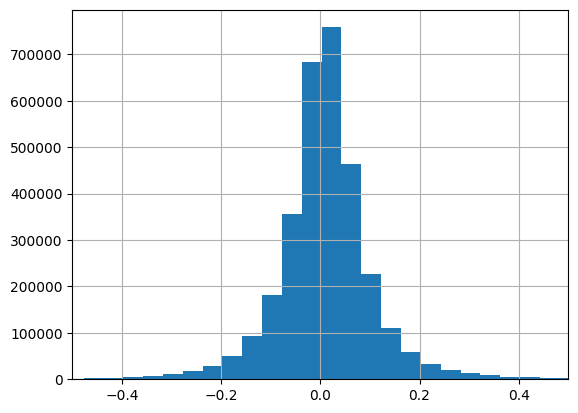

In [238]:
train[return_col].hist(bins=10000)
plt.xlim(-0.50, 0.50)

(-0.5, 0.5)

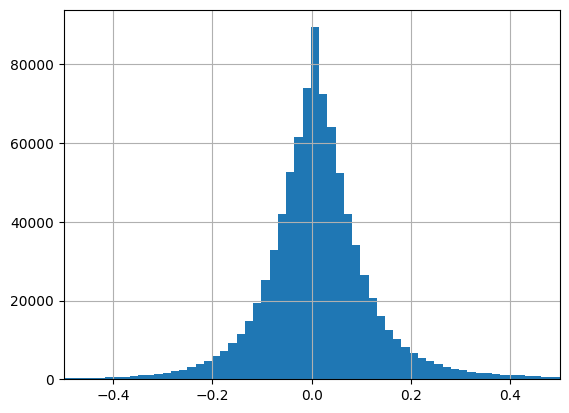

In [239]:
test[return_col].hist(bins=2500)
plt.xlim(-0.50, 0.50)

In [240]:
def compute_ic(df):

    ics = []

    for _, g in df.groupby("date"):
        if len(g) < 10:
            continue

        ic = g["pred"].corr(g["return_t+10"], method="spearman")
        ics.append(ic)

    return np.mean(ics)

def make_ic_eval(dates):

    def ic_eval(preds, dmatrix):
        labels = dmatrix.get_label()

        df = pd.DataFrame({
            "date": dates,
            "pred": preds,
            "ret": labels
        })

        df["pred_rank"] = df.groupby("date")["pred"].rank()
        df["ret_rank"] = df.groupby("date")["ret"].rank()

        ic_series = (
            df.groupby("date")
            .apply(lambda g: g["pred_rank"].corr(g["ret_rank"]))
            .dropna()
        )

        if len(ic_series) == 0:
            return "ic", 0.0

        return "ic", float(ic_series.mean())

    return ic_eval

# Precompute folds once
splitter = PurgedTimeSeriesSplit(
    n_splits=3,
    purge_days=14,
    embargo_days=5
)

FOLDS = list(splitter.split(train, train["date"]))

# ==========================================================
# Bayesian Objective Function
# ==========================================================

def objective(trial):

    print("\n" + "="*80)
    print(f"Starting Trial {trial.number}")

    params = {
        "objective": "reg:squarederror",
        # "objective": "rank:pairwise",
        "tree_method": "hist",
        # "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "learning_rate": 0.01,
        "max_depth": trial.suggest_int("max_depth", 1, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 500),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "lambda": trial.suggest_float("lambda", 1e-3, 10, log=True),
        "alpha": trial.suggest_float("alpha", 1e-3, 10, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "seed": 42
    }

    print("Params:")
    for k, v in params.items():
        print(f"  {k}: {v}")

    ic_scores = []

    for fold_num, (train_idx, val_idx) in enumerate(FOLDS):

        train_fold = train.loc[train_idx].sort_values("date")
        val_fold = train.loc[val_idx].sort_values("date")

        dtrain = xgb.DMatrix(
            train_fold[modeling_features],
            label=train_fold[return_col],
            enable_categorical=True
        )
        # dtrain.set_group(train_fold.groupby("date").size().values)

        dval = xgb.DMatrix(
            val_fold[modeling_features],
            label=val_fold[return_col],
            enable_categorical=True
        )
        # dval.set_group(val_fold.groupby("date").size().values)

        val_dates = val_fold["date"].values
        ic_eval_fn = make_ic_eval(val_dates)

        model = xgb.train(
            params,
            dtrain,
            evals=[(dval, "validation")],
            # custom_metric=ic_eval_fn,
            early_stopping_rounds=50,
            verbose_eval=25,
            num_boost_round=1000,
        )

        val_fold = val_fold.copy()
        val_fold["pred"] = model.predict(dval)

        fold_ic = compute_ic(val_fold)
        ic_scores.append(fold_ic)

        print(f"  Fold {fold_num} IC: {fold_ic:.6f}")

        trial.set_user_attr(f"fold_{fold_num}_ic", fold_ic)

    mean_ic = np.mean(ic_scores)
    std_ic = np.std(ic_scores)

    score = mean_ic / (std_ic + 1e-8)

    trial.set_user_attr("mean_ic", mean_ic)
    trial.set_user_attr("std_ic", std_ic)
    trial.set_user_attr("fold_ic_list", ic_scores)

    print(f"Trial {trial.number} Results:")
    print(f"  Mean IC: {mean_ic:.6f}")
    print(f"  Std IC:  {std_ic:.6f}")
    print(f"  IC / Std: {score:.6f}")
    print("="*80)

    return score


In [247]:
for i, (t_indices, v_indices) in enumerate(FOLDS):
    print("Fold", i + 1)
    print("-->", len(t_indices), min(train.loc[t_indices, "date"]), max(train.loc[t_indices, "date"]))
    print("-->", len(v_indices), min(train.loc[v_indices, "date"]), max(train.loc[v_indices, "date"]))


Fold 1
--> 2299302 2010-10-18 00:00:00 2022-04-29 00:00:00
--> 865771 2005-01-03 00:00:00 2010-10-11 00:00:00
Fold 2
--> 2090829 2005-01-03 00:00:00 2022-04-29 00:00:00
--> 1067836 2010-10-12 00:00:00 2016-07-21 00:00:00
Fold 3
--> 1925707 2005-01-03 00:00:00 2016-07-07 00:00:00
--> 1234158 2016-07-22 00:00:00 2022-04-29 00:00:00


## Run search

In [137]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(
    objective,
    n_trials=10,
    show_progress_bar=True
)

print("Best score:", study.best_value)
print("Best params:", study.best_params)

[I 2026-02-18 11:18:08,634] A new study created in memory with name: no-name-4d3a782c-1e5b-49d0-a083-0c9796402fe4
  0%|          | 0/10 [00:00<?, ?it/s]


Starting Trial 0
Params:
  objective: rank:pairwise
  tree_method: hist
  learning_rate: 0.01
  max_depth: 2
  min_child_weight: 476
  subsample: 0.892797576724562
  colsample_bytree: 0.8394633936788146
  lambda: 0.004207988669606638
  alpha: 0.004207053950287938
  gamma: 0.2904180608409973
  seed: 42


  0%|          | 0/10 [00:13<?, ?it/s]

[W 2026-02-18 11:18:21,735] Trial 0 failed with parameters: {'max_depth': 2, 'min_child_weight': 476, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'lambda': 0.004207988669606638, 'alpha': 0.004207053950287938, 'gamma': 0.2904180608409973} because of the following error: XGBoostError('[11:18:21] C:\\actions-runner\\_work\\xgboost\\xgboost\\src\\common\\ranking_utils.h:365: Check failed: label_is_integer: When using relevance degree as target, label must be either 0 or positive integer.').
Traceback (most recent call last):
  File "c:\Users\amsac\Desktop\repos\multimodal-stock-ranking\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\amsac\AppData\Local\Temp\ipykernel_5996\1620138336.py", line 130, in objective
    model = xgb.train(
        params,
    ...<6 lines>...
        num_boost_round=1000,
    )
  File "c:\Users\amsac\Desktop\repos\multimodal-stock-ranking\.venv\Lib\site-packa

XGBoostError: [11:18:21] C:\actions-runner\_work\xgboost\xgboost\src\common\ranking_utils.h:365: Check failed: label_is_integer: When using relevance degree as target, label must be either 0 or positive integer.

In [102]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_alpha,params_colsample_bytree,params_gamma,params_lambda,params_learning_rate,params_max_depth,params_min_child_weight,params_subsample,user_attrs_fold_0_ic,user_attrs_fold_1_ic,user_attrs_fold_2_ic,user_attrs_fold_ic_list,user_attrs_mean_ic,user_attrs_std_ic,state
0,0,4.335074,2026-02-18 10:14:52.761411,2026-02-18 10:16:59.501579,0 days 00:02:06.740168,0.001707,0.662407,4.330881,0.004207,0.043709,5,74,0.839463,0.039834,0.030256,0.022436,"[0.03983352429094121, 0.030255782310611944, 0....",0.030842,0.007114,COMPLETE
1,1,2.914110,2026-02-18 10:16:59.511304,2026-02-18 10:18:51.668396,0 days 00:01:52.157092,0.005337,0.932977,0.917023,0.007069,0.064100,4,3,0.987964,0.015512,0.013488,0.006152,"[0.015511756649239507, 0.013487754742406958, 0...",0.011717,0.004021,COMPLETE
2,2,3.465170,2026-02-18 10:18:51.671596,2026-02-18 10:20:36.993731,0 days 00:01:45.322135,0.014743,0.844741,1.831809,0.003614,0.037382,3,44,0.716492,0.044015,0.031309,0.021301,"[0.04401517652878496, 0.0313086223285921, 0.02...",0.032208,0.009295,COMPLETE
3,3,2.184232,2026-02-18 10:20:36.997204,2026-02-18 10:24:06.854454,0 days 00:03:29.857250,0.269265,0.836966,0.852621,0.001534,0.051046,4,20,0.805694,0.028555,0.008729,0.016261,"[0.02855497113239968, 0.008728960124795501, 0....",0.017848,0.008171,COMPLETE
4,4,2.925077,2026-02-18 10:24:06.861712,2026-02-18 10:26:08.453847,0 days 00:02:01.592135,0.545673,0.721846,2.200762,0.002459,0.015855,5,97,0.923359,0.039339,0.021466,0.018920,"[0.03933863880313855, 0.02146573618416306, 0.0...",0.026575,0.009085,COMPLETE
5,5,4.215150,2026-02-18 10:26:08.457719,2026-02-18 10:28:05.616154,0 days 00:01:57.158435,0.017654,0.703512,2.600340,0.446775,0.020983,3,4,0.963728,0.035079,0.025960,0.019547,"[0.035079114860970775, 0.025960462619388756, 0...",0.026862,0.006373,COMPLETE
6,6,3.150531,2026-02-18 10:28:05.620292,2026-02-18 10:29:56.575441,0 days 00:01:50.955149,0.246377,0.975800,4.609371,3.795853,0.059204,1,97,0.910053,0.041963,0.030683,0.018380,"[0.041962818919155966, 0.030682505763254493, 0...",0.030342,0.009631,COMPLETE
7,7,2.774474,2026-02-18 10:29:56.580029,2026-02-18 10:31:51.284217,0 days 00:01:54.704188,2.065143,0.755471,1.783767,0.012173,0.017964,1,5,0.730132,0.042959,0.031226,0.016370,"[0.042958579860629856, 0.031226355339157446, 0...",0.030185,0.010880,COMPLETE
8,8,4.744503,2026-02-18 10:31:51.287673,2026-02-18 10:33:57.225007,0 days 00:02:05.937334,1.227380,0.629820,0.993578,8.862327,0.035284,3,15,0.920879,0.037145,0.028799,0.022033,"[0.037145244412326306, 0.028799089541148338, 0...",0.029326,0.006181,COMPLETE
9,9,2.642018,2026-02-18 10:33:57.229550,2026-02-18 10:36:05.411994,0 days 00:02:08.182444,0.027156,0.908508,0.579345,0.001978,0.010497,5,71,0.891603,0.037324,0.018705,0.016978,"[0.03732383133676896, 0.01870549363968405, 0.0...",0.024336,0.009211,COMPLETE


## Train final model

In [104]:
best_params = study.best_trial.params
best_params

{'learning_rate': 0.03528410587186427,
 'max_depth': 3,
 'min_child_weight': 15,
 'subsample': 0.9208787923016158,
 'colsample_bytree': 0.6298202574719083,
 'lambda': 8.862326508576253,
 'alpha': 1.2273800987852967,
 'gamma': 0.993578407670862}

In [ ]:
best_params = study.best_trial.params

# Add fixed parameters back in
best_params.update({
    "objective": "rank:pairwise",
    "eval_metric": "ndcg",
    # "objective": "reg:squarederror",
    "tree_method": "hist",
    "seed": 42
})

In [ ]:
train = train.sort_values("date")

dtrain_full = xgb.DMatrix(
    train[modeling_features],
    label=train["return_t+10"],
    enable_categorical=True
)

# Set ranking groups (cross-sectional by date)
group_full = train.groupby("date").size().values
dtrain_full.set_group(group_full)

In [107]:
final_model = xgb.train(
    best_params,
    dtrain_full,
    num_boost_round=100  # same as HP search
)

In [114]:
train["pred"] = final_model.predict(dtrain_full)

### Predict on holdout set

In [111]:
test = test.sort_values("date")

dtest = xgb.DMatrix(
    test[modeling_features],
    enable_categorical=True
)
group_test = test.groupby("date").size().values
dtest.set_group(group_test)

test["pred"] = final_model.predict(dtest)


=== Strategy vs SPY Alpha (Intercept) and Beta (Slope) ===
Alpha: -0.006151  |  p-value: 0.005438
Beta:  0.664282  |  p-value: 0.000000

=== Strategy vs SPY Comparison ===
Metric                     Strategy            SPY
--------------------------------------------------
Annual Return                 2.79%         16.37%
Volatility                   10.67%         14.52%
Sharpe                         0.26           1.05
Max Drawdown                -15.84%        -13.32%
CAGR                          2.21%         17.80%


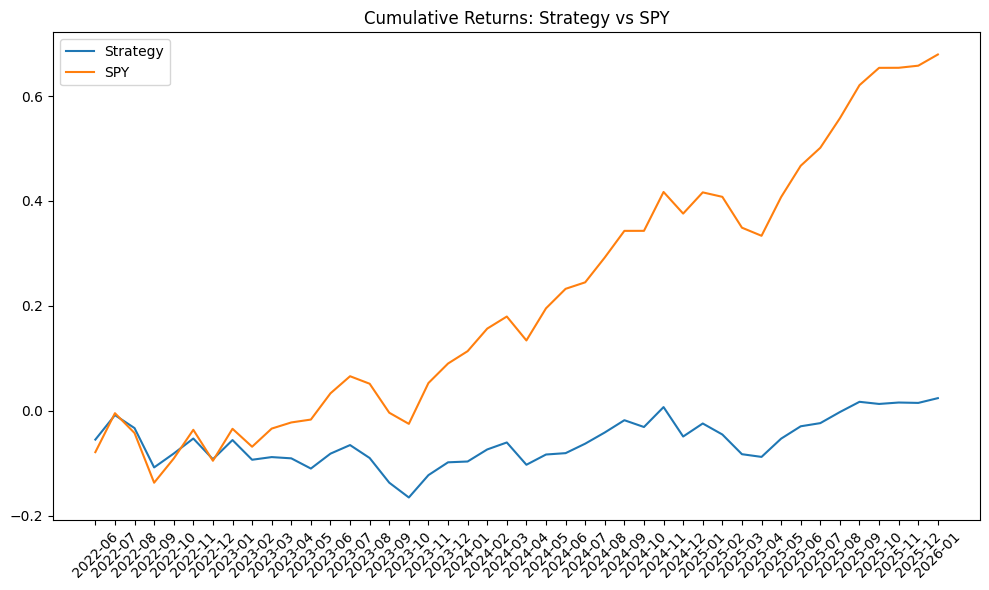

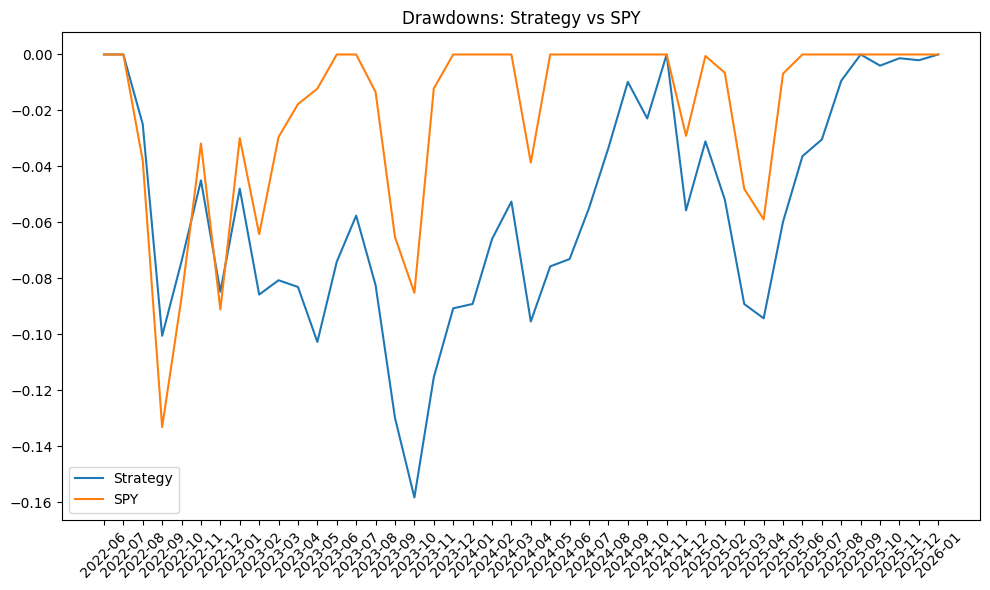

In [100]:
_ = backtest_monthly_dollar(
        test, 
        pred_col="pred", 
        long_class=None,         
        top_pct=0.20, 
        price_col="close",
        short_class=None,
        # short_pct=0.05,
        initial_capital=10000,
        transaction_cost_bps=20,
        monthly_contribution=0,
        short_term_tax_rate=0.35,
        borrow_cost_annual=0.03
)

# === Strategy vs SPY Alpha (Intercept) and Beta (Slope) ===
# Alpha: 0.000183  |  p-value: 0.962051
# Beta:  0.838798  |  p-value: 0.000000

# === Strategy vs SPY Comparison ===
# Metric                     Strategy            SPY
# --------------------------------------------------
# Annual Return                13.82%         16.37%
# Volatility                   14.74%         14.52%
# Sharpe                         0.88           1.05
# Max Drawdown                -13.65%        -13.32%
# CAGR                         12.64%         17.80%